<a href="https://colab.research.google.com/github/phaniidk/phaniidk-part-2-cnn-computer-vision/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import zipfile

with zipfile.ZipFile("images-20260517T065824Z-3-001.zip", 'r') as zip_ref:
    zip_ref.extractall("images")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)


In [7]:
labels_df = pd.read_csv("labels.csv")

print("First 5 Rows:")
print(labels_df.head())

print("\nDataset Shape:")
print(labels_df.shape)

print("\nColumns:")
print(labels_df.columns)

First 5 Rows:
                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal

Dataset Shape:
(480, 2)

Columns:
Index(['filename', 'class'], dtype='object')


In [8]:
image_column = labels_df.columns[0]
label_column = labels_df.columns[1]


In [9]:
print("\nUnique Classes:")
print(labels_df[label_column].unique())

print("\nNumber of Classes:")
print(labels_df[label_column].nunique())


Unique Classes:
['normal' 'scratch' 'dent' 'stain']

Number of Classes:
4


In [10]:
print("\nImages Per Class:")
print(labels_df[label_column].value_counts())


Images Per Class:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


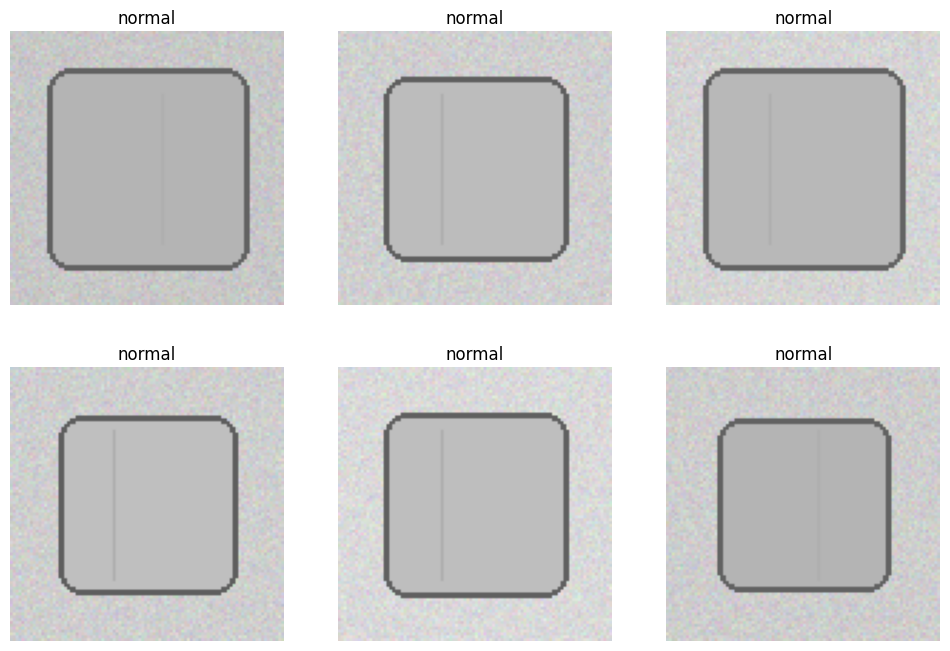

In [11]:
plt.figure(figsize=(12,8))

for i in range(6):

    image_name = labels_df.iloc[i][image_column]
    label = labels_df.iloc[i][label_column]

    image_path = os.path.join("images", image_name)

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(label)

    plt.axis('off')

plt.show()


In [12]:
IMG_SIZE = 128

images = []
labels = []

for index, row in labels_df.iterrows():

    image_name = row[image_column]

    label = row[label_column]

    image_path = os.path.join("images", image_name)

    img = cv2.imread(image_path)

    if img is not None:

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0

        images.append(img)

        labels.append(label)

In [13]:
X = np.array(images)

y = np.array(labels)

print("\nImage Dataset Shape:")
print(X.shape)


Image Dataset Shape:
(480, 128, 128, 3)


In [14]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:")
print(X_train.shape)

print("\nTesting Shape:")
print(X_test.shape)


Training Shape:
(384, 128, 128, 3)

Testing Shape:
(96, 128, 128, 3)


In [16]:
model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(len(np.unique(y)), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 777ms/step - accuracy: 0.2182 - loss: 2.5742 - val_accuracy: 0.2078 - val_loss: 1.4162
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 929ms/step - accuracy: 0.2606 - loss: 1.3992 - val_accuracy: 0.2338 - val_loss: 1.3833
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 844ms/step - accuracy: 0.3029 - loss: 1.3878 - val_accuracy: 0.2078 - val_loss: 1.3877
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 751ms/step - accuracy: 0.2736 - loss: 1.3816 - val_accuracy: 0.2338 - val_loss: 1.3806
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 904ms/step - accuracy: 0.4007 - loss: 1.3691 - val_accuracy: 0.3117 - val_loss: 1.3520
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 917ms/step - accuracy: 0.4072 - loss: 1.3224 - val_accuracy: 0.2078 - val_loss: 1.3597
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 735ms/step - accuracy: 0.4495 - loss: 1.2902 - val_accuracy: 0.3636 - val_loss: 1.3891
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 793ms/step - accuracy: 0.5244 - loss: 1.2013 - val_accuracy

In [19]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:")
print(accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.7708 - loss: 0.6730

Test Accuracy:
0.7708333134651184


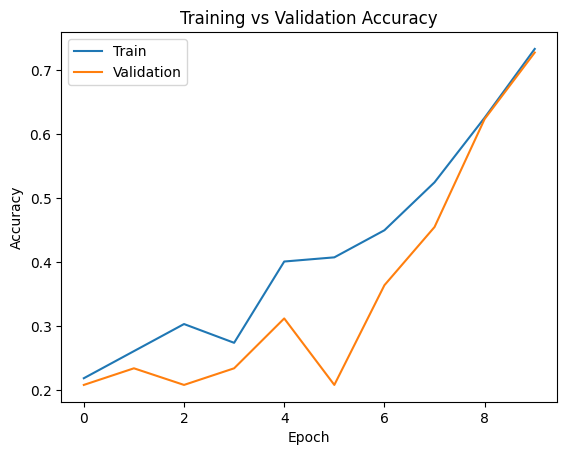

In [20]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.savefig("accuracy_loss_curves.png")

plt.show()

In [21]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step


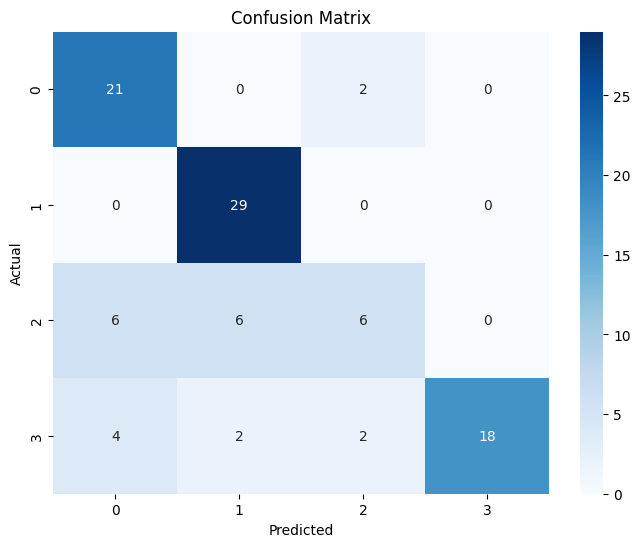

In [22]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()


In [23]:
print("\nClassification Report:")

print(classification_report(y_test, y_pred_classes))


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.91      0.78        23
           1       0.78      1.00      0.88        29
           2       0.60      0.33      0.43        18
           3       1.00      0.69      0.82        26

    accuracy                           0.77        96
   macro avg       0.77      0.73      0.73        96
weighted avg       0.78      0.77      0.75        96



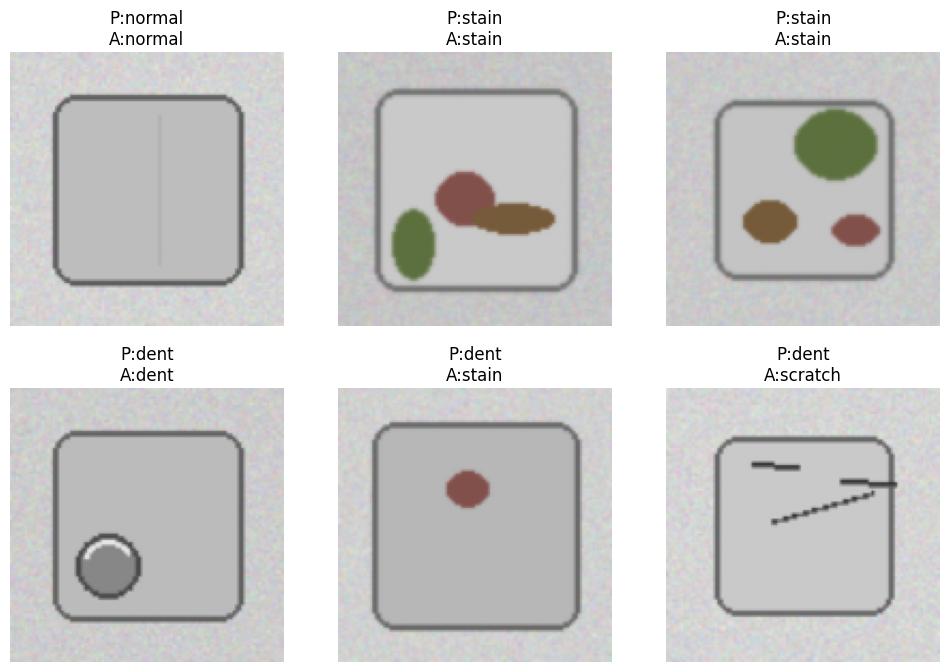


PROJECT COMPLETED SUCCESSFULLY


In [24]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])

    predicted_label = encoder.inverse_transform(
        [y_pred_classes[i]]
    )[0]

    actual_label = encoder.inverse_transform(
        [y_test[i]]
    )[0]

    plt.title(f"P:{predicted_label}\nA:{actual_label}")

    plt.axis('off')

plt.savefig("prediction_outputs.png")

plt.show()

print("\nPROJECT COMPLETED SUCCESSFULLY")